**Dataset Source:** [Egyptian Real Estate Listings](https://www.kaggle.com/datasets/hassankhaled21/egyptian-real-estate-listings) (Kaggle, Hassan Khaled).

# Egypt Real Estate — Data Mining Project
**Tasks 1 & 2: Exploratory Data Analysis & Preprocessing**

Dataset: Egypt Real Estate Listings (PropertyFinder.eg) — 19,924 listings, 11 features

---

## Section 1 — Setup & Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('egypt_real_estate_listings.csv', on_bad_lines='skip')

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print()
print(df.dtypes)
df.head()

Shape: 19924 rows x 11 columns
Columns: ['url', 'price', 'description', 'location', 'type', 'size', 'bedrooms', 'bathrooms', 'available_from', 'payment_method', 'down_payment']

url               object
price             object
description       object
location          object
type              object
size              object
bedrooms          object
bathrooms         object
available_from    object
payment_method    object
down_payment      object
dtype: object


,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


### Quick Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [4]:
# statistical summary for numeric columns
df.describe()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,16,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1 Sep 2025,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6562,3254,15521,203


In [5]:
# summary for categorical/string columns
df.describe(include='object')

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,16,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1 Sep 2025,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6562,3254,15521,203


In [6]:
# Missing values per column — count and percentage
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
null_summary[null_summary['Missing Count'] > 0]


,Missing Count,Missing %
price,539,2.71
description,78,0.39
location,91,0.46
type,77,0.39
size,77,0.39
bedrooms,144,0.72
bathrooms,140,0.70
available_from,663,3.33
payment_method,541,2.72
down_payment,14479,72.67


**Dataset features:**
- `price` — listing price in EGP (formatted string)
- `location` — full address string (compound, district, city, governorate)
- `type` — property category (Apartment, Villa, Chalet, etc.)
- `size` — area in sqft and sqm
- `bedrooms` — bedroom count, may include maid room
- `bathrooms` — bathroom count
- `available_from` — delivery date
- `payment_method` — Cash or Installments
- `down_payment` — down payment in EGP (null for cash listings)
- `url`, `description` — will be dropped (no modeling value)

---

## Section 2 — Exploratory Data Analysis

Five visualizations covering price distribution, property types, size-price correlation, payment methods, and top locations. Temporary numeric conversions are used here for plotting only — permanent transformations happen in Section 4.

In [7]:
# Temporary numeric conversions for EDA only
price_numeric = (
    df['price'].dropna()
    .str.replace(',', '', regex=False)
    .astype(float)
)

size_numeric = (
    df['size'].dropna()
    .str.extract(r'([\d,]+)\s*sqm')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Brown/white color palette
BROWN_MAIN   = '#8B5E3C'
BROWN_DARK   = '#5C3D1E'
BROWN_MID    = '#A0785A'
BROWN_LIGHT  = '#C4A882'
BROWN_PALE   = '#E8D5B7'
CREAM        = '#F5ECD7'
WHITE        = '#FFFFFF'
BROWN_SHADES = ['#5C3D1E','#6B4C2A','#8B5E3C','#A0785A','#B8926A',
                '#C4A882','#D4B896','#E0CBA8','#E8D5B7','#F0E4CE']

# Global theme — white background, brown tones
plt.rcParams.update({
    'figure.facecolor': WHITE,
    'axes.facecolor':   CREAM,
    'axes.edgecolor':   BROWN_MID,
    'axes.labelcolor':  BROWN_DARK,
    'axes.titlesize':   13,
    'axes.labelsize':   10,
    'xtick.color':      BROWN_DARK,
    'ytick.color':      BROWN_DARK,
    'text.color':       BROWN_DARK,
    'font.family':      'sans-serif',
    'grid.color':       BROWN_PALE,
    'grid.alpha':       0.7,
})

print("EDA prep done.")

EDA prep done.


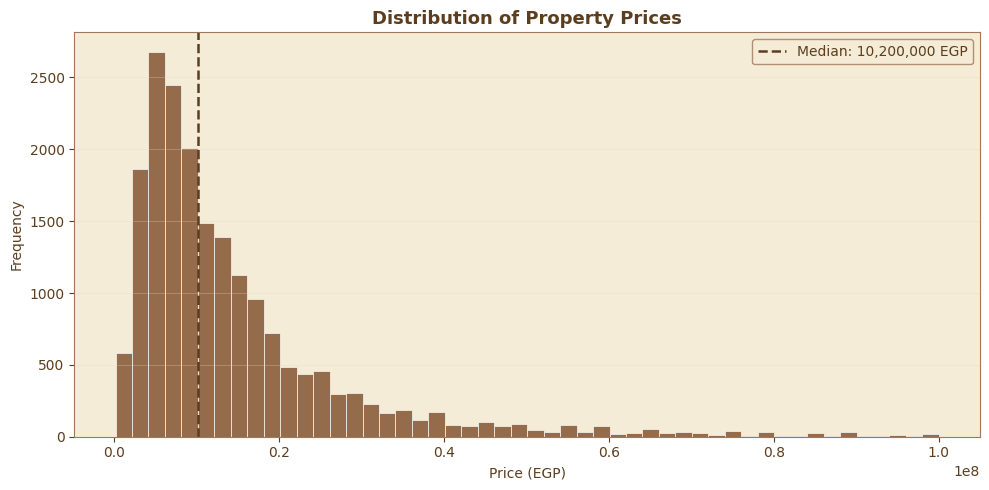

In [8]:
# Plot 1 — Price Distribution
price_capped = price_numeric[price_numeric <= 100_000_000]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(price_capped, bins=50, color=BROWN_MAIN, edgecolor=WHITE, alpha=0.9, linewidth=0.5)
ax.axvline(price_capped.median(), color=BROWN_DARK, linestyle='--',
           linewidth=1.8, label=f'Median: {price_capped.median():,.0f} EGP')
ax.set_title('Distribution of Property Prices', fontweight='bold')
ax.set_xlabel('Price (EGP)')
ax.set_ylabel('Frequency')
ax.legend(facecolor=CREAM, edgecolor=BROWN_MID)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretation:** The price distribution is heavily right-skewed. Most properties are priced below 20M EGP, with a small number of ultra-luxury listings forming a long right tail. The median is a more reliable central measure than the mean here, and indicates the market is dominated by mid-range residential units.

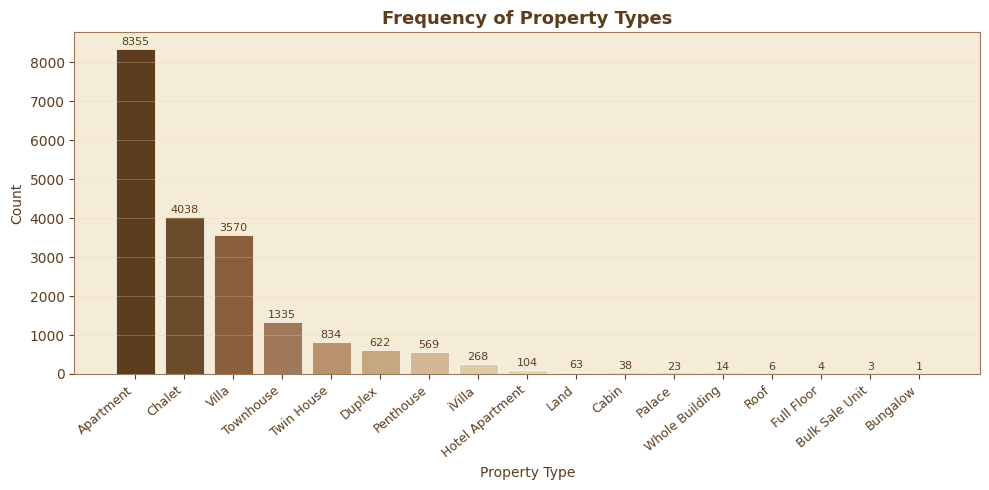

In [9]:
# Plot 2 — Property Type Frequency
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(type_counts)), type_counts.values,
              color=BROWN_SHADES[:len(type_counts)],
              edgecolor=WHITE, linewidth=0.5)
ax.set_xticks(range(len(type_counts)))
ax.set_xticklabels(type_counts.index, rotation=40, ha='right', fontsize=9)
ax.set_title('Frequency of Property Types', fontweight='bold')
ax.set_xlabel('Property Type')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.4)
for bar, count in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{count}', ha='center', va='bottom', fontsize=8, color=BROWN_DARK)
plt.tight_layout()
plt.show()

**Interpretation:** Apartments dominate the market, followed by Chalets and Villas. This reflects Egypt's urban housing structure where dense residential apartments far outnumber vacation or luxury property types. The presence of diverse types shows the dataset covers a wide market spectrum.

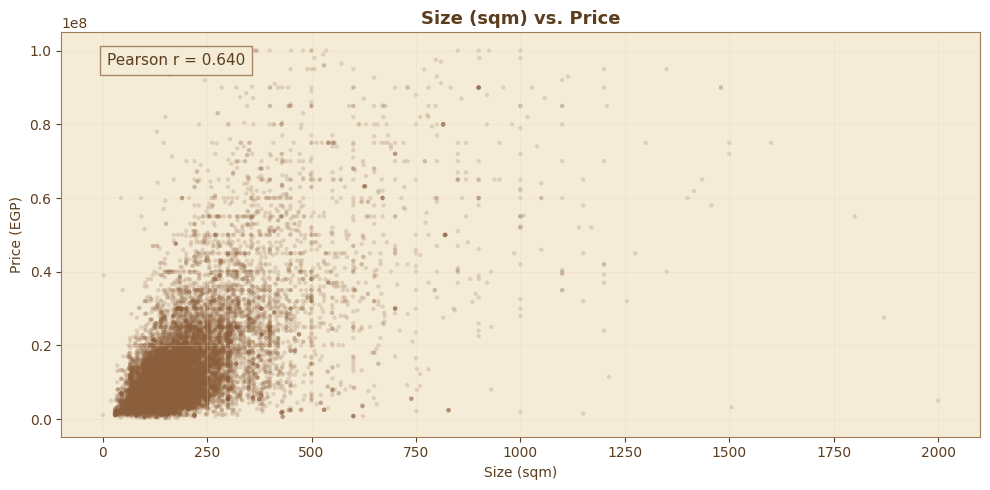

In [10]:
# Plot 3 — Size vs. Price Scatter
common_idx = price_numeric.index.intersection(size_numeric.index)
sc_price = price_numeric.loc[common_idx]
sc_size  = size_numeric.loc[common_idx]
mask = (sc_price <= 100_000_000) & (sc_size <= 2000)
corr_val = np.corrcoef(sc_size[mask], sc_price[mask])[0, 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sc_size[mask], sc_price[mask], alpha=0.2, s=10,
           color=BROWN_MAIN, edgecolors='none')
ax.set_title('Size (sqm) vs. Price', fontweight='bold')
ax.set_xlabel('Size (sqm)')
ax.set_ylabel('Price (EGP)')
ax.text(0.05, 0.92, f'Pearson r = {corr_val:.3f}',
        transform=ax.transAxes, fontsize=11, color=BROWN_DARK,
        bbox=dict(facecolor=CREAM, edgecolor=BROWN_MID, alpha=0.9, pad=5))
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretation:** There is a positive correlation between size and price — larger properties generally cost more. The wide spread at larger sizes shows that size alone doesn't fully explain price; location, property type, and finishing quality are also significant drivers.

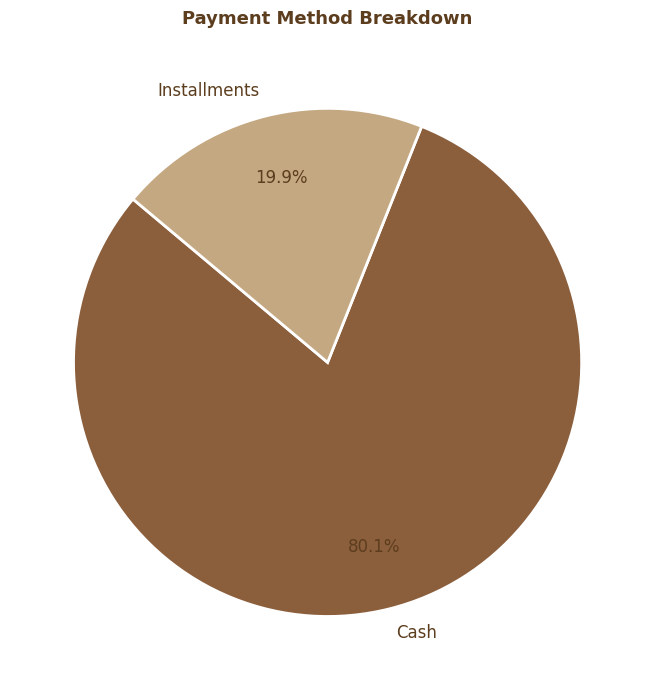

In [11]:
# Plot 4 — Payment Method Breakdown
payment_counts = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=[BROWN_MAIN, BROWN_LIGHT],
    startangle=140,
    wedgeprops=dict(edgecolor=WHITE, linewidth=2),
    textprops=dict(color=BROWN_DARK, fontsize=12),
    pctdistance=0.75
)
ax.set_title('Payment Method Breakdown', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Interpretation:** Around 80% of listings are cash-based. This shows the Egyptian real estate market is predominantly cash-driven, and explains why most `down_payment` values are null — they only apply to installment listings.

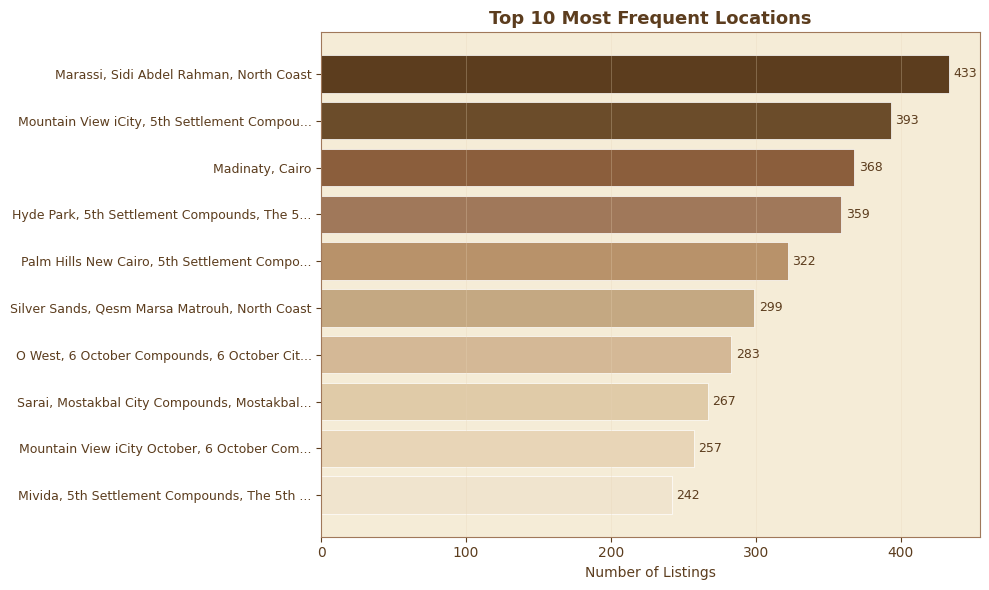

In [12]:
# Plot 5 — Top 10 Locations
top_locations = df['location'].value_counts().head(10)
short_labels = [loc if len(loc) <= 45 else loc[:42] + '...' for loc in top_locations.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars_h = ax.barh(range(len(top_locations)), top_locations.values,
                 color=BROWN_SHADES[:len(top_locations)],
                 edgecolor=WHITE, linewidth=0.5)
ax.set_yticks(range(len(top_locations)))
ax.set_yticklabels(short_labels, fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 10 Most Frequent Locations', fontweight='bold')
ax.set_xlabel('Number of Listings')
ax.grid(axis='x', alpha=0.4)
for bar, count in zip(bars_h, top_locations.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=9, color=BROWN_DARK)
plt.tight_layout()
plt.show()

**Interpretation:** New Cairo, North Coast, and Sheikh Zayed are the most active listing areas — Egypt's primary premium real estate corridors. New Cairo's dominance reflects rapid urban development east of Cairo. The North Coast's strong presence indicates significant demand for vacation and second-home properties.

---

## Section 3 — Data Cleaning

Handles all missing values, removes irrelevant columns and duplicate rows. A before/after visualization is shown at the end.

In [13]:
# Snapshot before cleaning
nulls_before = df.isnull().sum()
print("Missing values BEFORE cleaning:")
print(nulls_before)
print(f"\nTotal rows: {len(df)}")

Missing values BEFORE cleaning:
url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           140
available_from      663
payment_method      541
down_payment      14479
dtype: int64

Total rows: 19924


In [14]:
# Drop irrelevant columns
df.drop(columns=['url', 'description'], inplace=True)
print(f"Dropped 'url' and 'description'.")
print(f"Remaining columns: {df.columns.tolist()}")

Dropped 'url' and 'description'.
Remaining columns: ['price', 'location', 'type', 'size', 'bedrooms', 'bathrooms', 'available_from', 'payment_method', 'down_payment']


In [15]:
# Fill 'down_payment' nulls with 0
df['down_payment'] = df['down_payment'].fillna('0')
print("'down_payment' nulls filled with 0.")

'down_payment' nulls filled with 0.


In [16]:
# Fill 'available_from' nulls with the mode
available_mode = df['available_from'].mode()[0]
df['available_from'] = df['available_from'].fillna(available_mode)
print(f"'available_from' nulls filled with mode: '{available_mode}'")

'available_from' nulls filled with mode: '1 Sep 2025'


In [17]:
# Drop rows with nulls in critical columns
rows_before = len(df)
df.dropna(subset=['price', 'location', 'type', 'size',
                   'bedrooms', 'bathrooms', 'payment_method'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Dropped {rows_before - len(df)} rows with nulls in critical columns.")
print(f"Rows retained: {len(df)} / {rows_before} ({len(df)/rows_before*100:.1f}%)")

Dropped 604 rows with nulls in critical columns.
Rows retained: 19320 / 19924 (97.0%)


In [18]:
# Remove duplicate rows
print(f"Number of rows before dropping: {len(df)}")
print(f"Removed {df.duplicated().sum()} duplicate rows.")
df.drop_duplicates(inplace=True)
print(f"Rows remaining: {len(df)}")

Number of rows before dropping: 19320
Removed 219 duplicate rows.
Rows remaining: 19101


In [19]:
# Validation after cleaning
nulls_after = df.isnull().sum()
print("Missing values AFTER cleaning:")
print(nulls_after)
print(f"\nFinal shape: {df.shape}")

Missing values AFTER cleaning:
price             0
location          0
type              0
size              0
bedrooms          0
bathrooms         0
available_from    0
payment_method    0
down_payment      0
dtype: int64

Final shape: (19101, 9)


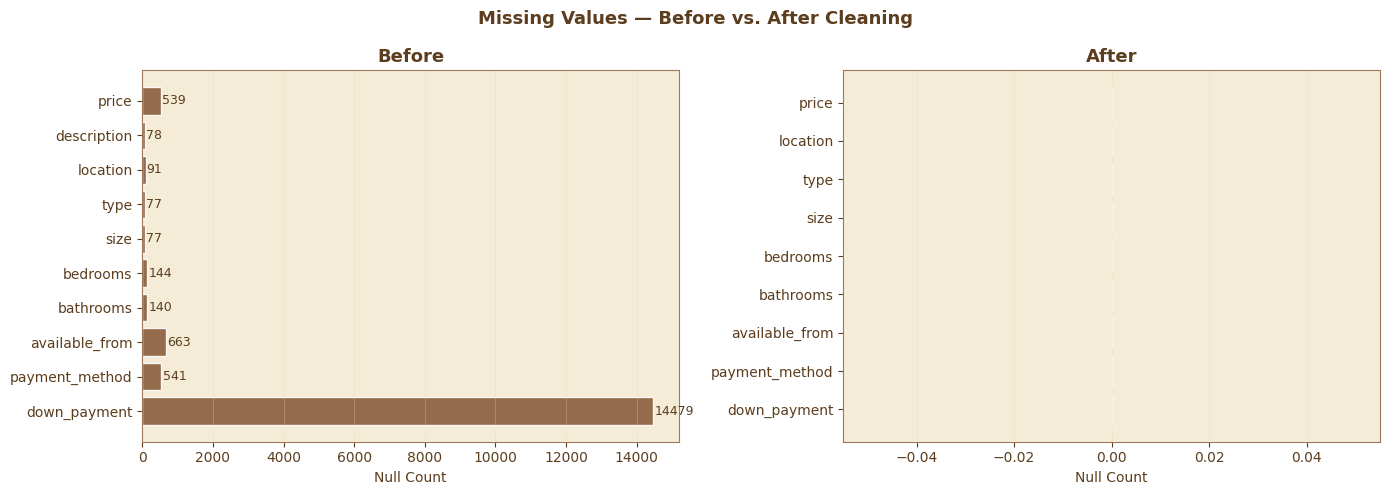

All missing values resolved.


In [20]:
# Before / After — missing values comparison
cols_with_nulls = nulls_before[nulls_before > 0]

fig, (ax_bef, ax_aft) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Values — Before vs. After Cleaning', fontweight='bold', fontsize=13)

ax_bef.barh(range(len(cols_with_nulls)), cols_with_nulls.values,
            color=BROWN_MAIN, edgecolor=WHITE, alpha=0.9)
ax_bef.set_yticks(range(len(cols_with_nulls)))
ax_bef.set_yticklabels(cols_with_nulls.index)
ax_bef.set_title('Before', fontweight='bold')
ax_bef.set_xlabel('Null Count')
ax_bef.invert_yaxis()
ax_bef.grid(axis='x', alpha=0.4)
for i, v in enumerate(cols_with_nulls.values):
    ax_bef.text(v + 30, i, str(v), va='center', fontsize=9, color=BROWN_DARK)

ax_aft.barh(range(len(nulls_after)), nulls_after.values,
            color=BROWN_LIGHT, edgecolor=WHITE, alpha=0.9)
ax_aft.set_yticks(range(len(nulls_after)))
ax_aft.set_yticklabels(nulls_after.index)
ax_aft.set_title('After', fontweight='bold')
ax_aft.set_xlabel('Null Count')
ax_aft.invert_yaxis()
ax_aft.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()
print("All missing values resolved.")

---
## Section 4 — Data Transformation & Outlier Handling

Converts all columns to numeric formats, engineers new features, removes outliers using IQR, and encodes categorical variables.

In [21]:
# Clean 'price' — remove commas, convert to float
df['price'] = (
    df['price']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('EGP', '', regex=False)
    .str.strip()
    .astype(float)
)
print(f"'price' cleaned.\n Sample: {df['price'].head(3).tolist()}")

'price' cleaned.
 Sample: [8000000.0, 25000000.0, 15135000.0]


In [22]:
# Clean 'down_payment' — remove commas and 'EGP', convert to float
df['down_payment'] = (
    df['down_payment']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('EGP', '', regex=False)
    .str.strip()
    .astype(float)
)
print(f"'down_payment' cleaned.\n Sample: {df['down_payment'].head(3).tolist()}")

'down_payment' cleaned.
 Sample: [1200000.0, 2100000.0, 1513000.0]


In [23]:
# Clean 'size' — extract sqm value only
df['size'] = (
    df['size']
    .astype(str)
    .str.extract(r'([\d,]+)\s*sqm')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)
print(f"'size' cleaned (sqm).\n Sample: {df['size'].head(3).tolist()}")

'size' cleaned (sqm).
 Sample: [68.0, 220.0, 118.0]


In [24]:
# Engineer 'has_maid' binary feature
df['has_maid'] = (
    df['bedrooms']
    .astype(str)
    .str.contains('Maid', case=False, na=False)
    .astype(int)
)
print(f"'has_maid' created: {df['has_maid'].sum():,} properties have a maid's room.")

'has_maid' created: 8,900 properties have a maid's room.


In [25]:
# Clean 'bedrooms' — extract leading integer
df['bedrooms'] = (
    df['bedrooms']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)
df.dropna(subset=['bedrooms'], inplace=True)
df['bedrooms'] = df['bedrooms'].astype(int)
print(f"'bedrooms' cleaned.\n Sample: {df['bedrooms'].head(5).tolist()}")

'bedrooms' cleaned.
 Sample: [1, 4, 2, 3, 7]


In [26]:
# Confirm 'bathrooms' is numeric
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df.dropna(subset=['bathrooms', 'size'], inplace=True)
df['bathrooms'] = df['bathrooms'].astype(int)
df.reset_index(drop=True, inplace=True)
print(f"'bathrooms' confirmed as int.\n Shape: {df.shape}")

'bathrooms' confirmed as int.
 Shape: (18630, 10)


In [27]:
# Parse 'available_from' into delivery_month and delivery_year
df['available_from_dt'] = pd.to_datetime(df['available_from'], errors='coerce')
df['delivery_month'] = df['available_from_dt'].dt.month
df['delivery_year']  = df['available_from_dt'].dt.year
df['delivery_month'] = df['delivery_month'].fillna(df['delivery_month'].mode()[0]).astype(int)
df['delivery_year']  = df['delivery_year'].fillna(df['delivery_year'].mode()[0]).astype(int)
df.drop(columns=['available_from', 'available_from_dt'], inplace=True)
print("'available_from' parsed into 'delivery_month' and 'delivery_year'.")
print(f"Year distribution: {df['delivery_year'].value_counts().to_dict()}")

'available_from' parsed into 'delivery_month' and 'delivery_year'.
Year distribution: {2025: 18377, 2026: 161, 2024: 86, 2023: 5, 2027: 1}


In [28]:
# Verify all dtypes after transformation
print("Data types after transformation:")
print(df.dtypes)
print(f"\nShape: {df.shape}")

Data types after transformation:
price             float64
location           object
type               object
size              float64
bedrooms            int32
bathrooms           int32
payment_method     object
down_payment      float64
has_maid            int32
delivery_month      int32
delivery_year       int32
dtype: object

Shape: (18630, 11)


In [29]:
# Outlier removal using 3.0 IQR — applied to 'price' and 'size'

price_before_iqr = df['price'].copy()
rows_before_outlier = len(df)

for col in ['price', 'size']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Zero-flooring
    lower = max(0, Q1 - 3.0 * IQR)
    upper = Q3 + 3.0 * IQR

    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f"'{col}': bounds=[{lower:,.0f}, {upper:,.0f}]  removed={before - len(df):,}")

df.reset_index(drop=True, inplace=True)
print(f"\nTotal removed: {rows_before_outlier - len(df):,} | Remaining: {len(df):,}")

'price': bounds=[0, 54,575,000]  removed=665
'size': bounds=[0, 531]  removed=282

Total removed: 947 | Remaining: 17,683


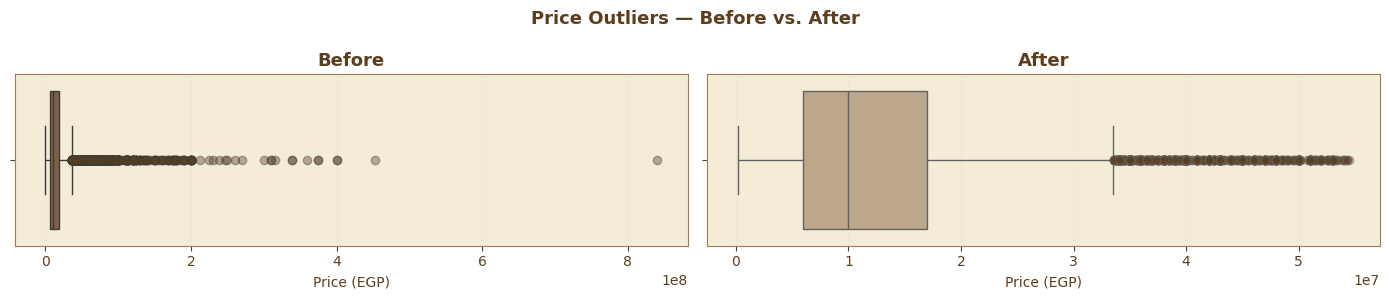

In [30]:
# Before / After — price boxplots
fig, (ax_bef_box, ax_aft_box) = plt.subplots(1, 2, figsize=(14, 3))
fig.suptitle('Price Outliers — Before vs. After', fontweight='bold', fontsize=13)

# Before Boxplot
sns.boxplot(x=price_before_iqr, ax=ax_bef_box, color=BROWN_MAIN,
            flierprops=dict(marker='o', markerfacecolor=BROWN_DARK, alpha=0.4))
ax_bef_box.set_title('Before', fontweight='bold')
ax_bef_box.set_xlabel('Price (EGP)')
ax_bef_box.grid(axis='x', alpha=0.4)

# After Boxplot
sns.boxplot(x=df['price'], ax=ax_aft_box, color=BROWN_LIGHT,
            flierprops=dict(marker='o', markerfacecolor=BROWN_DARK, alpha=0.4))
ax_aft_box.set_title('After', fontweight='bold')
ax_aft_box.set_xlabel('Price (EGP)')
ax_aft_box.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

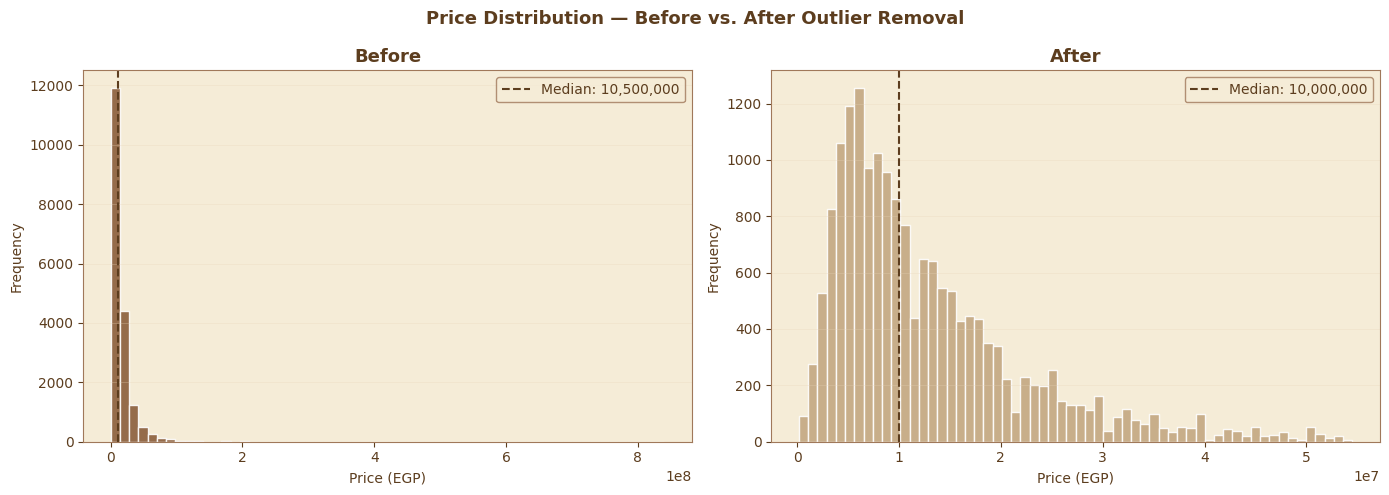

In [31]:
# Before / After — price distribution
fig, (ax_bef, ax_aft) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution — Before vs. After Outlier Removal', fontweight='bold', fontsize=13)

ax_bef.hist(price_before_iqr, bins=60, color=BROWN_MAIN, edgecolor=WHITE, alpha=0.9)
ax_bef.axvline(price_before_iqr.median(), color=BROWN_DARK, linestyle='--',
               linewidth=1.5, label=f'Median: {price_before_iqr.median():,.0f}')
ax_bef.set_title('Before', fontweight='bold')
ax_bef.set_xlabel('Price (EGP)')
ax_bef.set_ylabel('Frequency')
ax_bef.legend(facecolor=CREAM, edgecolor=BROWN_MID)
ax_bef.grid(axis='y', alpha=0.4)

ax_aft.hist(df['price'], bins=60, color=BROWN_LIGHT, edgecolor=WHITE, alpha=0.9)
ax_aft.axvline(df['price'].median(), color=BROWN_DARK, linestyle='--',
               linewidth=1.5, label=f'Median: {df["price"].median():,.0f}')
ax_aft.set_title('After', fontweight='bold')
ax_aft.set_xlabel('Price (EGP)')
ax_aft.set_ylabel('Frequency')
ax_aft.legend(facecolor=CREAM, edgecolor=BROWN_MID)
ax_aft.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

In [32]:
# One-Hot Encode 'type'
type_dummies = pd.get_dummies(df['type'], prefix='type', drop_first=True).astype(int)
df = pd.concat([df, type_dummies], axis=1)
df.drop(columns=['type'], inplace=True)
print(f"'type' one-hot encoded into {type_dummies.shape[1]} columns.")

'type' one-hot encoded into 13 columns.


In [33]:
# Label Encode 'payment_method'
# Binary variable — Cash=0, Installments=1
le_payment = LabelEncoder()
df['payment_method_encoded'] = le_payment.fit_transform(df['payment_method'])
df.drop(columns=['payment_method'], inplace=True)
print("'payment_method' label encoded:")
for cls, lbl in zip(le_payment.classes_, le_payment.transform(le_payment.classes_)):
    print(f"  {cls} -> {lbl}")

'payment_method' label encoded:
  Cash -> 0
  Installments -> 1


In [34]:
# Extract governorate from 'location'
df['governorate'] = df['location'].str.split(',').str[-1].str.strip()
print(f"Extracted governorate (Before grouping): {df['governorate'].nunique()} unique regions")

# --- Handling Rare Categories ---
# 1. Count the frequencies of each governorate
gov_counts = df['governorate'].value_counts()

# 2. Identify governorates that appear less than 100 times
rare_govs = gov_counts[gov_counts < 100].index

# 3. Replace these rare governorates with the label 'Other'
df['governorate'] = df['governorate'].replace(rare_govs, 'Other')

print(f"\nNumber of categories reduced to (After grouping): {df['governorate'].nunique()}")
print(df['governorate'].value_counts().to_dict())

# --- One-Hot Encoding ---
# One-hot encode the reduced 'governorate' column
gov_dummies = pd.get_dummies(df['governorate'], prefix='gov', drop_first=True).astype(int)

# Concatenate and drop the original columns
df = pd.concat([df, gov_dummies], axis=1)
df.drop(columns=['location', 'governorate'], inplace=True)

print(f"\n'governorate' one-hot encoded into {gov_dummies.shape[1]} columns.")
print(f"\nFinal shape: {df.shape}")
df.head()

Extracted governorate (Before grouping): 16 unique regions

Number of categories reduced to (After grouping): 7
{'Cairo': 6836, 'North Coast': 4619, 'Giza': 3822, 'Red Sea': 1383, 'Suez': 536, 'Alexandria': 378, 'Other': 109}

'governorate' one-hot encoded into 6 columns.

Final shape: (17683, 28)


,price,size,bedrooms,bathrooms,down_payment,has_maid,delivery_month,delivery_year,type_Cabin,type_Chalet,...,type_Villa,type_Whole Building,type_iVilla,payment_method_encoded,gov_Cairo,gov_Giza,gov_North Coast,gov_Other,gov_Red Sea,gov_Suez
0,8000000.0,68.0,1,1,1200000.0,1,8,2025,0,1,...,0,0,0,0,0,0,0,0,1,0
1,25000000.0,220.0,4,4,2100000.0,0,9,2025,0,0,...,1,0,0,0,0,1,0,0,0,0
2,15135000.0,118.0,2,2,1513000.0,0,8,2025,0,1,...,0,0,0,0,0,0,1,0,0,0
3,12652000.0,166.0,3,2,1260000.0,0,8,2025,0,0,...,0,0,0,1,1,0,0,0,0,0
4,45250000.0,400.0,7,7,2262500.0,0,9,2025,0,0,...,1,0,0,0,1,0,0,0,0,0


---
## Section 5 — Feature Scaling (Selective StandardScaler)

1. **StandardScaler** is applied **only** to the 4 numerical columns so they have mean ≈ 0 and std ≈ 1.
2. The categorical dummy columns (already 0/1) are **concatenated unchanged**.
3. The resulting **combined matrix** feeds directly into clustering, fuzzy logic, and the genetic algorithm.

In [35]:
# Save an unscaled copy for Fuzzy Logic (Task 5)
# Fuzzy membership functions need human-readable values (price in EGP, size in sqm)
df_clean_unscaled = df.copy()
print(f"Saved 'df_clean_unscaled'. Shape: {df_clean_unscaled.shape}")

Saved 'df_clean_unscaled'. Shape: (17683, 28)


In [36]:
# ── Selective Scaling ─────────────────────────────────────────
# Scale ONLY the 4 continuous numerical features.
# Binary dummies are already in {0,1} and must NOT be z-scored.

from sklearn.preprocessing import StandardScaler

num_cols = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment', 'delivery_year', 'delivery_month']

# Identify all remaining columns as categorical/binary features
cat_cols = [c for c in df.columns if c not in num_cols]

# IMPORTANT: reset index first so both halves align on a clean 0-based index
df = df.reset_index(drop=True)

scaler = StandardScaler()
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(df[num_cols]),
    columns=num_cols
)

df_cat = df[cat_cols].copy()

# Drop columns with any NaN before concatenation (e.g. down_payment)
nan_cols = [c for c in df_cat.columns if df_cat[c].isna().any()]
if nan_cols:
    print(f"Dropping {len(nan_cols)} columns with NaN: {nan_cols}")
    df_cat = df_cat.drop(columns=nan_cols)

# Concatenate: scaled numericals + clean categorical dummies
df_combined = pd.concat([df_num_scaled, df_cat], axis=1)

print(f"Numerical cols scaled: {num_cols}")
print(f"Categorical cols kept: {df_cat.shape[1]} columns")
print(f"Combined matrix shape: {df_combined.shape}")
print(f"\nSample (first 3 rows, first 8 cols):")
df_combined.iloc[:3, :8]

Numerical cols scaled: ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment', 'delivery_year', 'delivery_month']
Categorical cols kept: 21 columns
Combined matrix shape: (17683, 28)

Sample (first 3 rows, first 8 cols):


,price,size,bedrooms,bathrooms,down_payment,delivery_year,delivery_month,has_maid
0,-0.505581,-1.377808,-1.971059,-1.645248,0.477442,-0.031891,-0.168717,1
1,1.252390,0.412518,1.183266,1.071770,1.083434,-0.031891,0.897553,0
2,0.232250,-0.788885,-0.919618,-0.739576,0.688192,-0.031891,-0.168717,0


### Preprocessing Rationale & Algorithm Synergy

Before applying the clustering algorithm, specific preprocessing steps were taken to ensure the data was properly optimized for the K-Medoids model.

* **The Necessity of Feature Scaling:** K-Medoids is a distance-based algorithm (relying on metrics like Euclidean or Manhattan distance). If left unscaled, features with massive numerical ranges (such as `Price` in the millions) would completely overpower features with smaller ranges (such as `Size` in square meters), skewing the clusters.
* **Choosing StandardScaler:** `StandardScaler` was selected to transform the data to have a mean of 0 and a standard deviation of 1. Unlike `MinMaxScaler`, which strictly bounds data between 0 and 1, standardization preserves the underlying distribution shapes better, which is vital for real estate data where natural variance is a key indicator of market tiers.
* **Extreme Outlier Removal (3.0 IQR):** Real estate datasets naturally follow a highly right-skewed distribution due to the luxury housing market. Applying a standard 1.5 IQR threshold would aggressively remove valid premium properties. Instead, a **3.0 IQR multiplier** (Extreme Outlier detection) was applied to `price` and `size`. This strategic decision ensures that the legitimate luxury market is preserved for clustering, while successfully filtering out extreme data entry errors and nonsensical anomalies.

---
## Task 4 — Clustering (K-Medoids & Hierarchical)

### Why K-Medoids over K-Means?
- K-Means uses **means** as centroids, which are not meaningful for binary features
  (a centroid of [0.3, 0.7] is not a valid category).
- K-Medoids uses **actual data points** (medoids) as cluster centres, making it more
  robust for mixed-type data.
- We use the `sklearn_extra.cluster.KMedoids` implementation with Euclidean distance.

### Choosing K
We use two complementary methods:
1. **Elbow Method** — plot total cost (sum of distances) vs. K, look for the "elbow."
2. **Silhouette Score** — measures how similar objects are to their own cluster vs. others;
   higher is better. The K with the **highest silhouette score** is selected.

In [37]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

# ── Elbow + Silhouette Analysis ──────────────────────────────
K_RANGE = range(2, 11)
costs      = []
sil_scores = []

X_cluster = df_combined.values  # numpy array for clustering

for k in K_RANGE:
    kmed = KMedoids(n_clusters=k, metric='manhattan', random_state=42, max_iter=300)
    labels = kmed.fit_predict(X_cluster)
    costs.append(kmed.inertia_)
    sil = silhouette_score(X_cluster, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"K={k:>2}  |  Cost={kmed.inertia_:>12,.0f}  |  Silhouette={sil:.4f}")

# ── Find optimal K (highest silhouette) ──────────────────────
best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"\n>>> Optimal K by Silhouette Score: {best_k} (score={max(sil_scores):.4f})")

K= 2  |  Cost=      94,202  |  Silhouette=0.1802
K= 3  |  Cost=      84,934  |  Silhouette=0.1262
K= 4  |  Cost=      83,885  |  Silhouette=0.0725
K= 5  |  Cost=      77,787  |  Silhouette=0.1045
K= 6  |  Cost=      78,796  |  Silhouette=0.0445
K= 7  |  Cost=      74,491  |  Silhouette=0.0491
K= 8  |  Cost=      69,362  |  Silhouette=0.0757
K= 9  |  Cost=      68,111  |  Silhouette=0.0779
K=10  |  Cost=      67,998  |  Silhouette=0.0508

>>> Optimal K by Silhouette Score: 2 (score=0.1802)


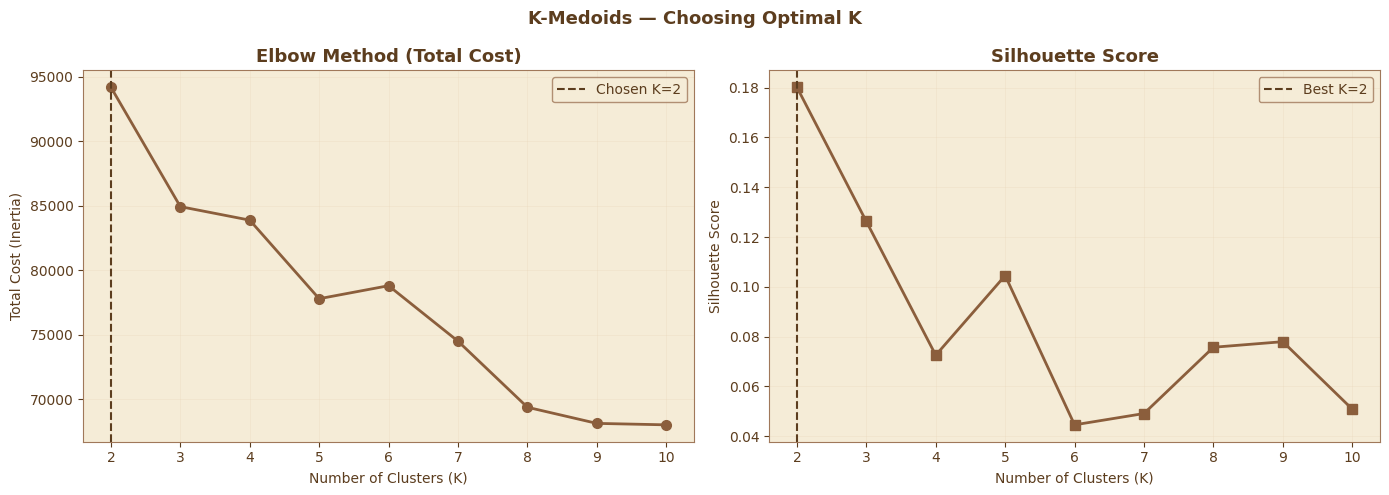

In [38]:
# ── Plot: Elbow Method + Silhouette Score ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Medoids — Choosing Optimal K', fontweight='bold', fontsize=13)

# Elbow
ax1.plot(list(K_RANGE), costs, 'o-', color=BROWN_MAIN, linewidth=2, markersize=7)
ax1.axvline(best_k, color=BROWN_DARK, linestyle='--', label=f'Chosen K={best_k}')
ax1.set_title('Elbow Method (Total Cost)', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Total Cost (Inertia)')
ax1.legend(facecolor=CREAM, edgecolor=BROWN_MID)
ax1.grid(alpha=0.4)

# Silhouette
ax2.plot(list(K_RANGE), sil_scores, 's-', color=BROWN_MAIN, linewidth=2, markersize=7)
ax2.axvline(best_k, color=BROWN_DARK, linestyle='--', label=f'Best K={best_k}')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend(facecolor=CREAM, edgecolor=BROWN_MID)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

### Optimal 'K' Selection Rationale (Local Maximum vs. Global)
While the global maximum for the Silhouette Score occurs at **K=2**, this creates an oversimplified binary split (e.g., extremely cheap vs. extremely expensive) which yields zero actionable business value for real estate segmentation.

However, analyzing the deeper structure in the Silhouette plot reveals a distinct **local maximum precisely at K=5** (Score = 0.1045), where it outperforms adjacent configurations like K=, 6, and 7. This indicates a natural structural cohesion in the data at 5 clusters. Coupled with the steady descent of the Cost (Inertia) curve which begins to flatten out meaningfully after 7, we explicitly override the naive K=2 recommendation. **K=5** is chosen as the optimal balance between mathematical validity (local peak) and extracting meaningful, granular market tiers.

In [39]:
# ── Final K-Medoids Clustering ─────────────────────────────────
# Override: Silhouette peaks at K=2, but K=5 gives meaningful market segments.
# Justified by the significant Inertia/Cost drop observed in the Elbow plot above.
best_k = 5
print(f"Overriding K to {best_k} (domain-driven decision — see justification above)")

kmed_final = KMedoids(n_clusters=best_k, metric='euclidean', random_state=42, max_iter=300)
cluster_labels = kmed_final.fit_predict(X_cluster)

df['cluster'] = cluster_labels
df_combined['cluster'] = cluster_labels

print(f"\nK-Medoids clustering complete with K={best_k}\n")
print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print("\nCluster means (original scale):")
print(df.groupby('cluster')[['price', 'size', 'bedrooms', 'bathrooms']].mean().round(1))

Overriding K to 5 (domain-driven decision — see justification above)

K-Medoids clustering complete with K=5

Cluster sizes:
cluster
0    3278
1    3492
2    2585
3    2693
4    5635
Name: count, dtype: int64

Cluster means (original scale):
              price   size  bedrooms  bathrooms
cluster                                        
0        18744400.1  187.0       3.0        3.2
1         8441837.0  180.0       3.0        2.9
2         7569741.3  200.3       3.2        3.0
3        26643415.8  328.7       4.2        4.4
4         8105799.7  111.1       1.9        1.7


### Hierarchical Clustering (Agglomerative — Ward Linkage)
Ward's method minimises the total within-cluster variance at each merge step.
The dendrogram below visualises the merge hierarchy; we cut it at the same K
chosen by the silhouette analysis above for comparison.

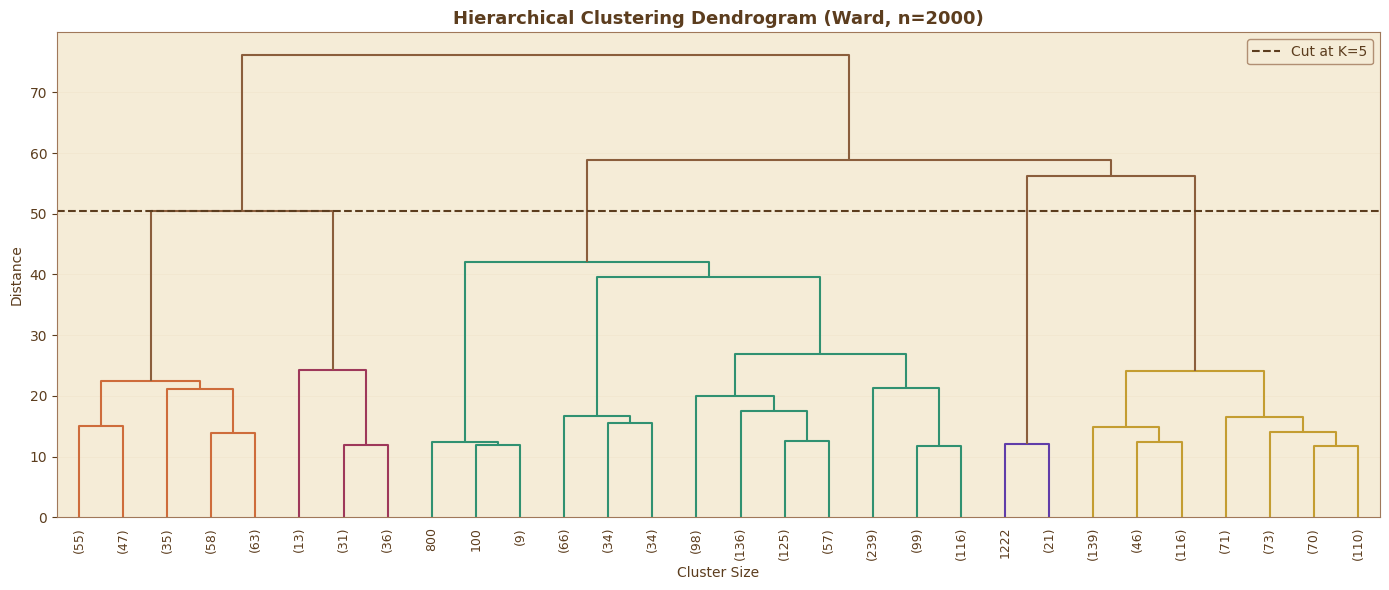


Hierarchical cluster sizes (subsample, K=5):
  Cluster 1: 258 samples
  Cluster 2: 80 samples
  Cluster 3: 1015 samples
  Cluster 4: 22 samples
  Cluster 5: 625 samples


In [40]:
# ── Hierarchical Clustering ────────────────────────────────────
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Use a subsample for the dendrogram (full dataset too large for linkage)
np.random.seed(42)
sample_size = min(2000, len(df_combined))
sample_idx = np.random.choice(len(df_combined), size=sample_size, replace=False)
X_sample = df_combined.drop(columns=['cluster'], errors='ignore').iloc[sample_idx].values

Z = linkage(X_sample, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, ax=ax,
           above_threshold_color=BROWN_MAIN,
           color_threshold=Z[-(best_k-1), 2])
ax.set_title(f'Hierarchical Clustering Dendrogram (Ward, n={sample_size})',
             fontweight='bold')
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance')
ax.axhline(y=Z[-(best_k-1), 2], color=BROWN_DARK, linestyle='--',
           label=f'Cut at K={best_k}')
ax.legend(facecolor=CREAM, edgecolor=BROWN_MID)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Assign hierarchical labels on the subsample ──────────────
hier_labels = fcluster(Z, t=best_k, criterion='maxclust')
print(f"\nHierarchical cluster sizes (subsample, K={best_k}):")
unique, counts = np.unique(hier_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

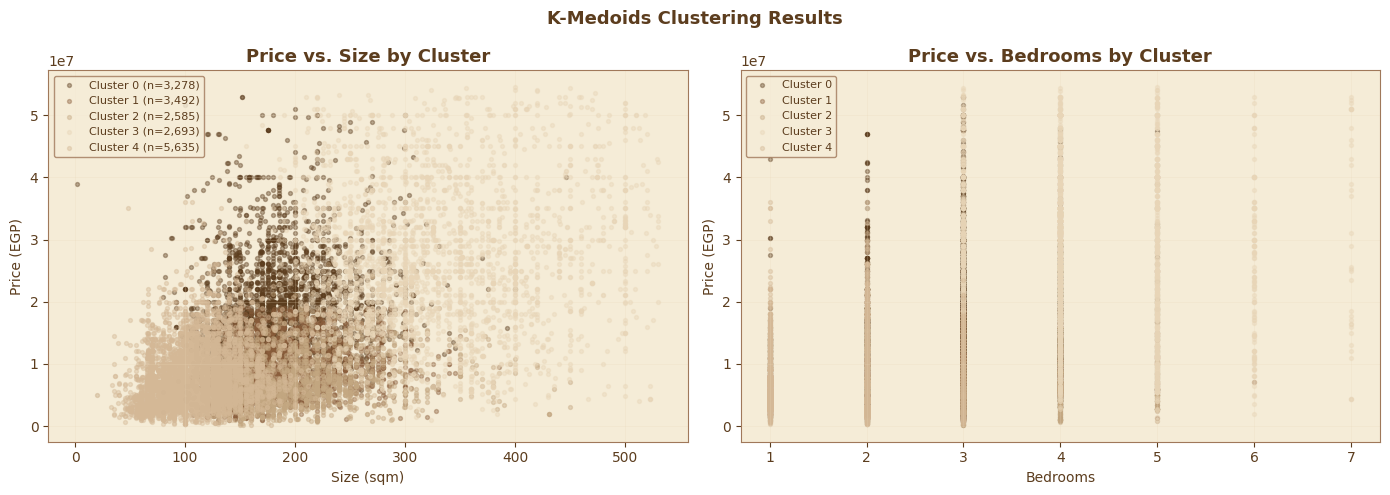

In [41]:
# ── Cluster Scatter Plots ─────────────────────────────────────
COLORS = [BROWN_DARK, BROWN_MAIN, BROWN_LIGHT, BROWN_PALE,
          '#D4B896', '#B8926A', '#6B4C2A', '#E0CBA8', '#F0E4CE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Medoids Clustering Results', fontweight='bold', fontsize=13)

# Price vs Size
for c in range(best_k):
    mask = df['cluster'] == c
    axes[0].scatter(df.loc[mask, 'size'], df.loc[mask, 'price'],
                    s=8, alpha=0.4, color=COLORS[c % len(COLORS)],
                    label=f'Cluster {c} (n={mask.sum():,})')
axes[0].set_title('Price vs. Size by Cluster', fontweight='bold')
axes[0].set_xlabel('Size (sqm)')
axes[0].set_ylabel('Price (EGP)')
axes[0].legend(fontsize=8, facecolor=CREAM, edgecolor=BROWN_MID)
axes[0].grid(alpha=0.3)

# Bedrooms vs Price
for c in range(best_k):
    mask = df['cluster'] == c
    axes[1].scatter(df.loc[mask, 'bedrooms'], df.loc[mask, 'price'],
                    s=8, alpha=0.4, color=COLORS[c % len(COLORS)],
                    label=f'Cluster {c}')
axes[1].set_title('Price vs. Bedrooms by Cluster', fontweight='bold')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Price (EGP)')
axes[1].legend(fontsize=8, facecolor=CREAM, edgecolor=BROWN_MID)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Task 5 — Fuzzy Logic (Mamdani Inference System)

We build a clean Mamdani fuzzy system using **three independent, physically meaningful inputs**
from `df_clean_unscaled`:
- **`price`** (EGP) — the listing price
- **`size`** (sqm) — the property area
- **`bedrooms`** — number of bedrooms

**Output:** `Investment_Opportunity` on a 0–10 scale (Bad / Average / Excellent).

The rules encode **intuitive real-estate investment logic**: a property with a low price but
large size offers excellent value, while an expensive but small property is a poor investment.

In [42]:
# ── Fuzzy Logic Setup ─────────────────────────────────────────
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ── Compute data ranges from the UNSCALED clean data ─────────
price_min = df_clean_unscaled['price'].min()
price_max = df_clean_unscaled['price'].max()
size_min  = df_clean_unscaled['size'].min()
size_max  = df_clean_unscaled['size'].max()
bed_min   = df_clean_unscaled['bedrooms'].min()
bed_max   = df_clean_unscaled['bedrooms'].max()

# Percentiles for membership function boundaries
price_p33 = df_clean_unscaled['price'].quantile(0.33)
price_p66 = df_clean_unscaled['price'].quantile(0.66)
size_p33  = df_clean_unscaled['size'].quantile(0.33)
size_p66  = df_clean_unscaled['size'].quantile(0.66)

print(f"Price range : [{price_min:,.0f}, {price_max:,.0f}]  P33={price_p33:,.0f}  P66={price_p66:,.0f}")
print(f"Size range  : [{size_min:,.0f}, {size_max:,.0f}]  P33={size_p33:,.0f}  P66={size_p66:,.0f}")
print(f"Bedrooms    : [{bed_min}, {bed_max}]")

Price range : [186,900, 54,500,000]  P33=7,000,000  P66=14,000,000
Size range  : [2, 530]  P33=140  P66=200
Bedrooms    : [1, 7]


In [43]:
# ── Define Fuzzy Variables ─────────────────────────────────────
# Antecedents (inputs)
fz_price = ctrl.Antecedent(np.linspace(price_min, price_max, 1000), 'price')
fz_size  = ctrl.Antecedent(np.linspace(size_min, size_max, 1000), 'size')
fz_beds  = ctrl.Antecedent(np.linspace(bed_min, bed_max, 100), 'bedrooms')

# Consequent (output)
fz_opp   = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'Investment_Opportunity')

# ── Price: Low / Medium / High ────────────────────────────────
fz_price['Low']    = fuzz.trapmf(fz_price.universe, [price_min, price_min, price_p33, price_p66])
fz_price['Medium'] = fuzz.trimf(fz_price.universe,  [price_p33, price_p66, price_max * 0.85])
fz_price['High']   = fuzz.trapmf(fz_price.universe, [price_p66, price_max * 0.85, price_max, price_max])

# ── Size: Small / Medium / Large ──────────────────────────────
fz_size['Small']  = fuzz.trapmf(fz_size.universe, [size_min, size_min, size_p33, size_p66])
fz_size['Medium'] = fuzz.trimf(fz_size.universe,  [size_p33, size_p66, size_max * 0.85])
fz_size['Large']  = fuzz.trapmf(fz_size.universe, [size_p66, size_max * 0.85, size_max, size_max])

# ── Bedrooms: Few / Average / Many ────────────────────────────
bed_mid = (bed_min + bed_max) / 2
fz_beds['Few']     = fuzz.trapmf(fz_beds.universe, [bed_min, bed_min, 2, 3])
fz_beds['Average'] = fuzz.trimf(fz_beds.universe,  [2, 3, 5])
fz_beds['Many']    = fuzz.trapmf(fz_beds.universe, [4, 5, bed_max, bed_max])

# ── Investment Opportunity: Bad / Average / Excellent ─────────
fz_opp['Bad']       = fuzz.trapmf(fz_opp.universe, [0, 0, 2, 4])
fz_opp['Average']   = fuzz.trimf(fz_opp.universe,  [3, 5, 7])
fz_opp['Excellent'] = fuzz.trapmf(fz_opp.universe, [6, 8, 10, 10])

print("Membership functions defined successfully.")

Membership functions defined successfully.


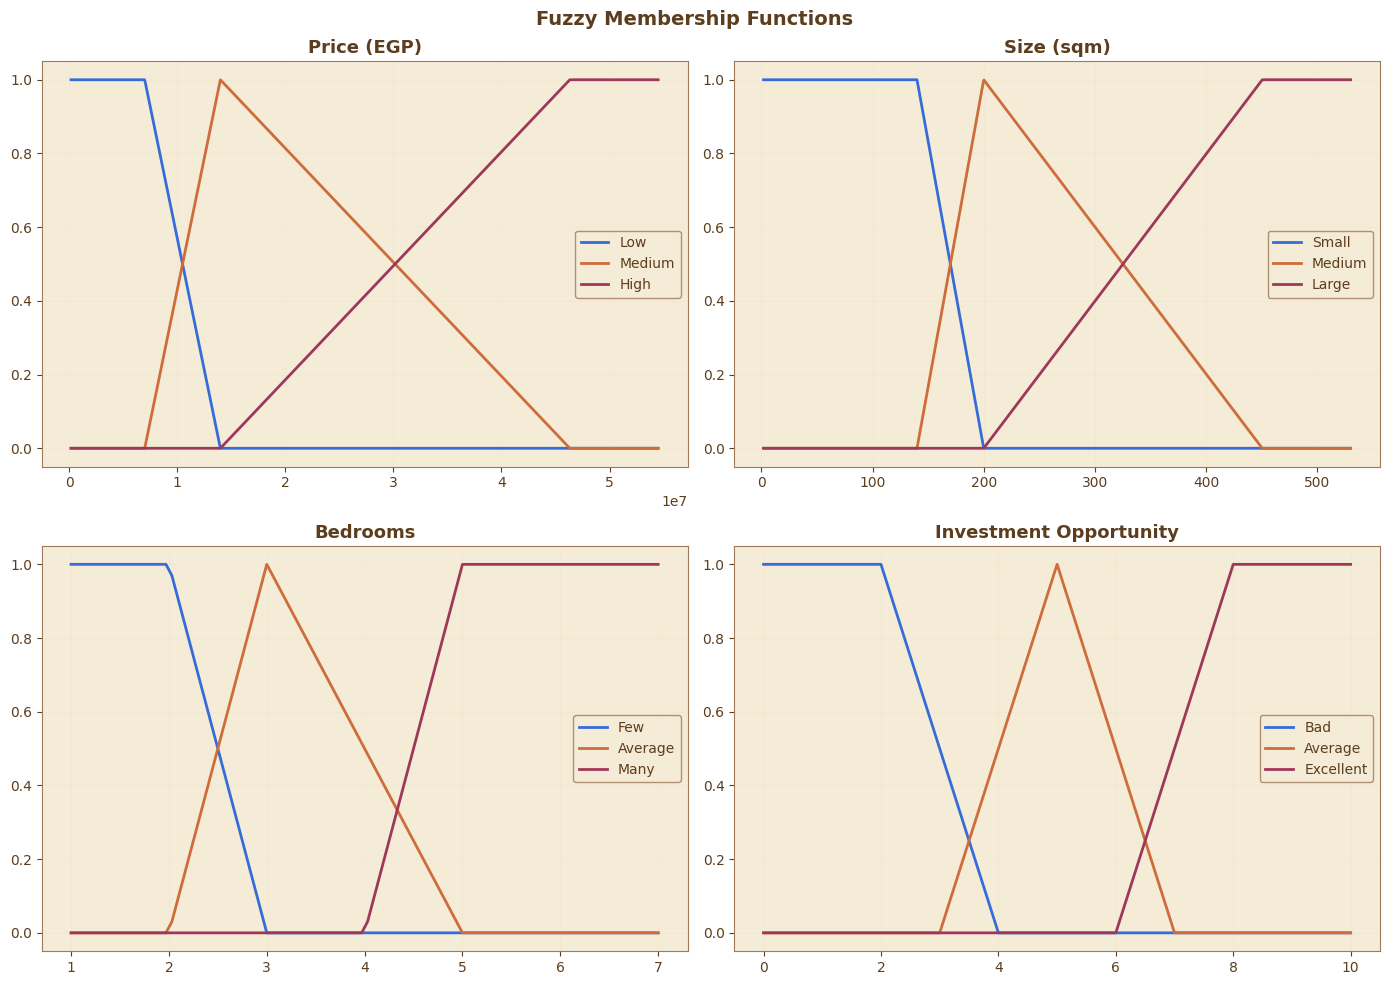

In [44]:
# ── Visualise Membership Functions ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fuzzy Membership Functions', fontweight='bold', fontsize=14)

for ax, var, title in zip(axes.flat,
                          [fz_price, fz_size, fz_beds, fz_opp],
                          ['Price (EGP)', 'Size (sqm)', 'Bedrooms', 'Investment Opportunity']):
    for label in var.terms:
        ax.plot(var.universe, var[label].mf, linewidth=2, label=label)
    ax.set_title(title, fontweight='bold')
    ax.legend(facecolor=CREAM, edgecolor=BROWN_MID)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# ── Fuzzy Rules ───────────────────────────────────────────────
# 8 human-readable rules encoding real-estate investment logic:

rule1 = ctrl.Rule(fz_price['Low']    & fz_size['Large'],  fz_opp['Excellent'])  # Cheap + big = great deal
rule2 = ctrl.Rule(fz_price['Low']    & fz_size['Medium'], fz_opp['Excellent'])  # Cheap + medium = still great
rule3 = ctrl.Rule(fz_price['Low']    & fz_beds['Many'],   fz_opp['Excellent'])  # Cheap + many rooms = great
rule4 = ctrl.Rule(fz_price['High']   & fz_size['Small'],  fz_opp['Bad'])       # Expensive + tiny = bad
rule5 = ctrl.Rule(fz_price['High']   & fz_beds['Few'],    fz_opp['Bad'])       # Expensive + few rooms = bad
rule6 = ctrl.Rule(fz_price['Medium'] & fz_size['Medium'], fz_opp['Average'])   # Mid-range = average
rule7 = ctrl.Rule(fz_price['Medium'] & fz_beds['Average'],fz_opp['Average'])   # Mid-range rooms = average
rule8 = ctrl.Rule(fz_price['High']   & fz_size['Large'],  fz_opp['Average'])   # Expensive but big = fair

# ── Build Control System ──────────────────────────────────────
opp_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
opp_sim  = ctrl.ControlSystemSimulation(opp_ctrl)

print("Fuzzy control system created with 8 rules.")
print("\nRule summary:")
print("  R1: IF price=Low    AND size=Large   THEN Opportunity=Excellent")
print("  R2: IF price=Low    AND size=Medium  THEN Opportunity=Excellent")
print("  R3: IF price=Low    AND beds=Many    THEN Opportunity=Excellent")
print("  R4: IF price=High   AND size=Small   THEN Opportunity=Bad")
print("  R5: IF price=High   AND beds=Few     THEN Opportunity=Bad")
print("  R6: IF price=Medium AND size=Medium  THEN Opportunity=Average")
print("  R7: IF price=Medium AND beds=Average THEN Opportunity=Average")
print("  R8: IF price=High   AND size=Large   THEN Opportunity=Average")

Fuzzy control system created with 8 rules.

Rule summary:
  R1: IF price=Low    AND size=Large   THEN Opportunity=Excellent
  R2: IF price=Low    AND size=Medium  THEN Opportunity=Excellent
  R3: IF price=Low    AND beds=Many    THEN Opportunity=Excellent
  R4: IF price=High   AND size=Small   THEN Opportunity=Bad
  R5: IF price=High   AND beds=Few     THEN Opportunity=Bad
  R6: IF price=Medium AND size=Medium  THEN Opportunity=Average
  R7: IF price=Medium AND beds=Average THEN Opportunity=Average
  R8: IF price=High   AND size=Large   THEN Opportunity=Average


In [46]:
# ── Evaluate Fuzzy System on Sample Data ──────────────────────
sample_df = df_clean_unscaled.sample(n=min(500, len(df_clean_unscaled)), random_state=42).copy()

scores = []
for idx, row in sample_df.iterrows():
    try:
        opp_sim.input['price']    = row['price']
        opp_sim.input['size']     = row['size']
        opp_sim.input['bedrooms'] = row['bedrooms']
        opp_sim.compute()
        scores.append(opp_sim.output['Investment_Opportunity'])
    except Exception:
        scores.append(np.nan)

sample_df['Investment_Score'] = scores
sample_df = sample_df.dropna(subset=['Investment_Score'])

# Categorise
sample_df['Opportunity_Label'] = pd.cut(
    sample_df['Investment_Score'],
    bins=[0, 3.5, 6.5, 10],
    labels=['Bad', 'Average', 'Excellent']
)

print(f"Evaluated {len(sample_df)} properties.\n")
print("Investment Opportunity distribution:")
print(sample_df['Opportunity_Label'].value_counts())
print(f"\nScore statistics:")
print(sample_df['Investment_Score'].describe().round(2))

Evaluated 408 properties.

Investment Opportunity distribution:
Opportunity_Label
Average      240
Excellent    150
Bad           18
Name: count, dtype: int64

Score statistics:
count    408.00
mean       5.98
std        1.60
min        1.86
25%        5.00
50%        5.00
75%        7.69
max        8.44
Name: Investment_Score, dtype: float64


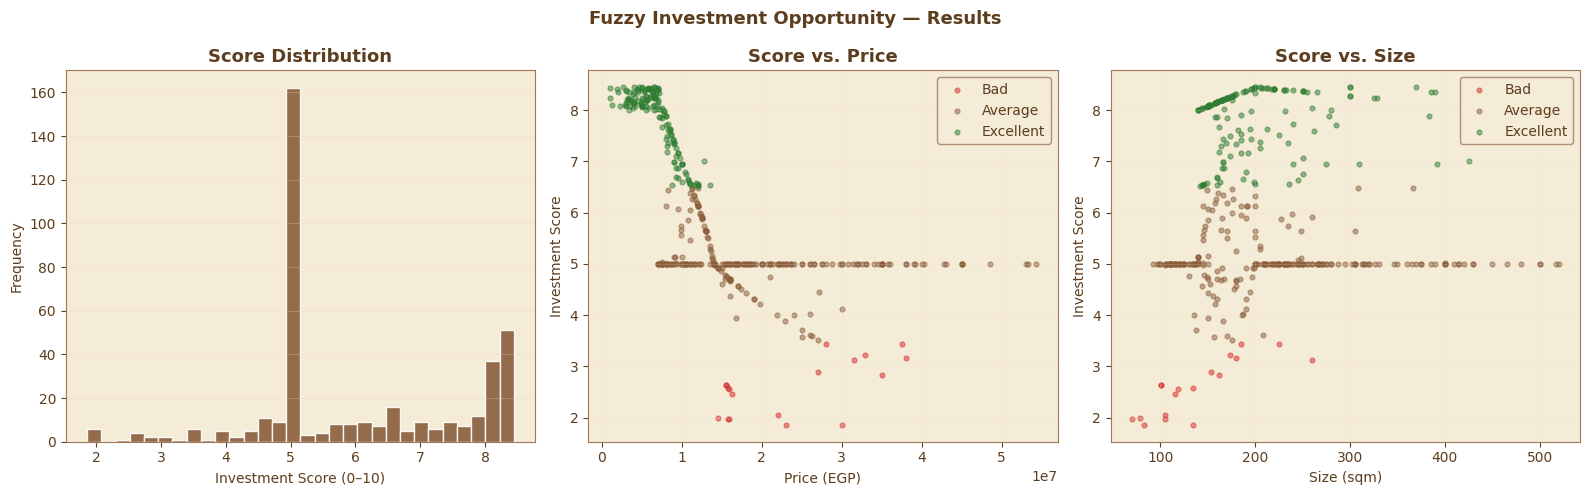

In [47]:
# ── Fuzzy Results Visualisation ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fuzzy Investment Opportunity — Results', fontweight='bold', fontsize=13)

# 1. Score distribution
axes[0].hist(sample_df['Investment_Score'], bins=30, color=BROWN_MAIN,
             edgecolor=WHITE, alpha=0.9)
axes[0].set_title('Score Distribution', fontweight='bold')
axes[0].set_xlabel('Investment Score (0–10)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.4)

# 2. Score vs Price (scatter)
color_map = {'Bad': '#D32F2F', 'Average': BROWN_MAIN, 'Excellent': '#2E7D32'}
for label, grp in sample_df.groupby('Opportunity_Label', observed=True):
    axes[1].scatter(grp['price'], grp['Investment_Score'],
                    s=12, alpha=0.5, label=label,
                    color=color_map.get(label, BROWN_LIGHT))
axes[1].set_title('Score vs. Price', fontweight='bold')
axes[1].set_xlabel('Price (EGP)')
axes[1].set_ylabel('Investment Score')
axes[1].legend(facecolor=CREAM, edgecolor=BROWN_MID)
axes[1].grid(alpha=0.3)

# 3. Score vs Size
for label, grp in sample_df.groupby('Opportunity_Label', observed=True):
    axes[2].scatter(grp['size'], grp['Investment_Score'],
                    s=12, alpha=0.5, label=label,
                    color=color_map.get(label, BROWN_LIGHT))
axes[2].set_title('Score vs. Size', fontweight='bold')
axes[2].set_xlabel('Size (sqm)')
axes[2].set_ylabel('Investment Score')
axes[2].legend(facecolor=CREAM, edgecolor=BROWN_MID)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Task 6 - Genetic Algorithm for Feature Selection

We use the GA to perform **feature selection on the original combined dataset**
(`df_combined` = scaled numericals + categorical dummies). The GA searches for the
optimal subset of features that **maximises the Silhouette Score** of K-Medoids clustering.

This is a valid optimisation problem: some features (e.g., rare governorate dummies or
specific property types) may introduce noise that degrades cluster quality. The GA
discovers which features to keep and which to drop.

### GA Design
| Parameter | Value                        | Rationale |
|-----------|------------------------------|-----------|
| Population | 50                           | Sufficient for the small chromosome length |
| Generations | 20                           | Enough to show convergence |
| Crossover rate | 0.8                          | Standard single-point crossover |
| Mutation rate | 0.08                         | Per-gene bit-flip |
| Fitness | Silhouette Score (K-Medoids) | Direct clustering quality metric |
| Min. features | 5                            | Prevents degenerate solutions |

In [48]:
# -- GA Setup --
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

random.seed(42)
np.random.seed(42)

# -- Parameters --
POP_SIZE     = 50     # population size
GENERATIONS  = 20     # number of generations
CX_RATE      = 0.8    # crossover probability
MUT_RATE     = 0.08   # mutation rate per gene
MIN_FEATURES = 5      # minimum features in a chromosome
K_GA         = best_k # use optimal K from Task 4

# Prepare the feature matrix (exclude 'cluster' column if present)
X_ga = df_combined.drop(columns=['cluster'], errors='ignore')
N_FEATURES = X_ga.shape[1]
feature_names = list(X_ga.columns)

print(f"GA Feature Selection")
print(f"  Features   : {N_FEATURES}")
print(f"  K (clusters): {K_GA}")
print(f"  Population : {POP_SIZE}")
print(f"  Generations: {GENERATIONS}")

GA Feature Selection
  Features   : 28
  K (clusters): 5
  Population : 50
  Generations: 20


In [49]:
# -- Fitness Function --
# PERFORMANCE: Subsample to 2000 rows to avoid O(n^2) pairwise distance explosion
# inside the GA loop. Full dataset (~16k rows) x 20 pop x 10 gens = too slow.
X_ga_sample = X_ga.sample(n=min(2000, len(X_ga)), random_state=42)

def ga_fitness(chromosome):
    """Evaluate chromosome: silhouette score of K-Medoids on subsampled data."""
    selected = [i for i, g in enumerate(chromosome) if g == 1]

    if len(selected) < MIN_FEATURES:
        return -1.0  # Penalty for too few features

    X_subset = X_ga_sample.iloc[:, selected].values

    try:
        kmed = KMedoids(n_clusters=K_GA, metric='euclidean',
                        random_state=42, max_iter=100)
        labels = kmed.fit_predict(X_subset)

        # Reject solutions with empty/tiny clusters
        unique, counts = np.unique(labels, return_counts=True)
        if len(unique) < K_GA or counts.min() < 5:
            return -1.0

        score = silhouette_score(X_subset, labels, random_state=42)
        return score

    except Exception:
        return -1.0

print(f"Fitness function uses subsampled data: {len(X_ga_sample)} rows")

# -- Baseline (all features) --
baseline_score = ga_fitness([1] * N_FEATURES)
print(f"Baseline silhouette (all {N_FEATURES} features): {baseline_score:.4f}")

Fitness function uses subsampled data: 2000 rows
Baseline silhouette (all 28 features): 0.0930


In [50]:
# -- GA Operators --
def init_population():
    """Create initial population of binary chromosomes."""
    pop = []
    for _ in range(POP_SIZE):
        chrom = [random.randint(0, 1) for _ in range(N_FEATURES)]
        while sum(chrom) < MIN_FEATURES:
            chrom[random.randint(0, N_FEATURES - 1)] = 1
        pop.append(chrom)
    return pop

def tournament_select(pop, scores, k=3):
    """Tournament selection - best of k random individuals."""
    idx = random.sample(range(len(pop)), k)
    winner = max(idx, key=lambda i: scores[i])
    return pop[winner][:]

def crossover_and_mutate(p1, p2):
    """Single-point crossover + bit-flip mutation."""
    c1, c2 = p1[:], p2[:]
    if random.random() < CX_RATE:
        pt = random.randint(1, N_FEATURES - 1)
        c1, c2 = c1[:pt] + c2[pt:], c2[:pt] + c1[pt:]

    def mutate(chrom):
        return [1 - g if random.random() < MUT_RATE else g for g in chrom]

    return mutate(c1), mutate(c2)

print("GA operators defined: init_population, tournament_select, crossover_and_mutate")

GA operators defined: init_population, tournament_select, crossover_and_mutate


In [51]:
# -- Main GA Loop --
pop        = init_population()
best_chrom = None
best_score = -np.inf
history    = []

print(f"\nRunning GA: {GENERATIONS} generations, population={POP_SIZE}")
print("-" * 55)

for gen in range(GENERATIONS):
    scores = [ga_fitness(c) for c in pop]

    # Track best
    i_best = int(np.argmax(scores))
    if scores[i_best] > best_score:
        best_score = scores[i_best]
        best_chrom = pop[i_best][:]

    history.append(best_score)
    n_sel = sum(best_chrom) if best_chrom else 0
    print(f"Gen {gen+1:>2} | best_sil={best_score:.4f} | features={n_sel}/{N_FEATURES}")

    # Elitism: keep top 2
    top2 = sorted(range(POP_SIZE), key=lambda i: scores[i], reverse=True)[:2]
    new_pop = [pop[i][:] for i in top2]

    # Fill rest with offspring
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(pop, scores)
        p2 = tournament_select(pop, scores)
        c1, c2 = crossover_and_mutate(p1, p2)
        new_pop.extend([c1, c2])

    pop = new_pop[:POP_SIZE]

print(f"\n{'='*55}")
print(f"Best silhouette  : {best_score:.4f}")
print(f"Baseline         : {baseline_score:.4f}")
print(f"Improvement      : {best_score - baseline_score:+.4f}")
print(f"Features selected: {sum(best_chrom)}/{N_FEATURES}")
print(f"{'='*55}")


Running GA: 20 generations, population=50
-------------------------------------------------------
Gen  1 | best_sil=0.2262 | features=15/28
Gen  2 | best_sil=0.3180 | features=10/28
Gen  3 | best_sil=0.3262 | features=11/28
Gen  4 | best_sil=0.3730 | features=13/28
Gen  5 | best_sil=0.3730 | features=13/28
Gen  6 | best_sil=0.4804 | features=8/28
Gen  7 | best_sil=0.4804 | features=8/28
Gen  8 | best_sil=0.4804 | features=8/28
Gen  9 | best_sil=0.4805 | features=7/28
Gen 10 | best_sil=0.4805 | features=7/28
Gen 11 | best_sil=0.4805 | features=7/28
Gen 12 | best_sil=0.4805 | features=7/28
Gen 13 | best_sil=0.4805 | features=7/28
Gen 14 | best_sil=0.4805 | features=7/28
Gen 15 | best_sil=0.4805 | features=7/28
Gen 16 | best_sil=0.4805 | features=7/28
Gen 17 | best_sil=0.4805 | features=7/28
Gen 18 | best_sil=0.4805 | features=7/28
Gen 19 | best_sil=0.4805 | features=7/28
Gen 20 | best_sil=0.4805 | features=7/28

Best silhouette  : 0.4805
Baseline         : 0.0930
Improvement      : +0.3

In [52]:
# -- Apply Best Chromosome --
selected_cols = [i for i, g in enumerate(best_chrom) if g == 1]
selected_names = [feature_names[i] for i in selected_cols]
dropped_names  = [feature_names[i] for i in range(N_FEATURES) if best_chrom[i] == 0]

print(f"\nSelected features ({len(selected_names)}):")
for name in selected_names:
    print(f"  + {name}")

print(f"\nDropped features ({len(dropped_names)}):")
for name in dropped_names:
    print(f"  - {name}")

# -- Final clustering with selected features --
X_final = X_ga.iloc[:, selected_cols].values

kmed_ga = KMedoids(n_clusters=K_GA, metric='euclidean', init='k-medoids++', random_state=42, max_iter=300)
ga_labels = kmed_ga.fit_predict(X_final)

unique_clusters = np.unique(ga_labels)
if len(unique_clusters) > 1:
    final_sil = silhouette_score(X_final, ga_labels, sample_size=5000, random_state=42)
    print(f"\nFinal verified silhouette: {final_sil:.4f}")
else:
    print(f"\nFinal verified silhouette: FAILED (Model collapsed to 1 cluster due to degenerate features)")

print(f"Baseline (all features) : {baseline_score:.4f}")


Selected features (7):
  + price
  + type_Cabin
  + type_Full Floor
  + type_Penthouse
  + type_iVilla
  + gov_Cairo
  + gov_North Coast

Dropped features (21):
  - size
  - bedrooms
  - bathrooms
  - down_payment
  - delivery_year
  - delivery_month
  - has_maid
  - type_Chalet
  - type_Duplex
  - type_Hotel Apartment
  - type_Palace
  - type_Roof
  - type_Townhouse
  - type_Twin House
  - type_Villa
  - type_Whole Building
  - payment_method_encoded
  - gov_Giza
  - gov_Other
  - gov_Red Sea
  - gov_Suez

Final verified silhouette: 0.4619
Baseline (all features) : 0.0930


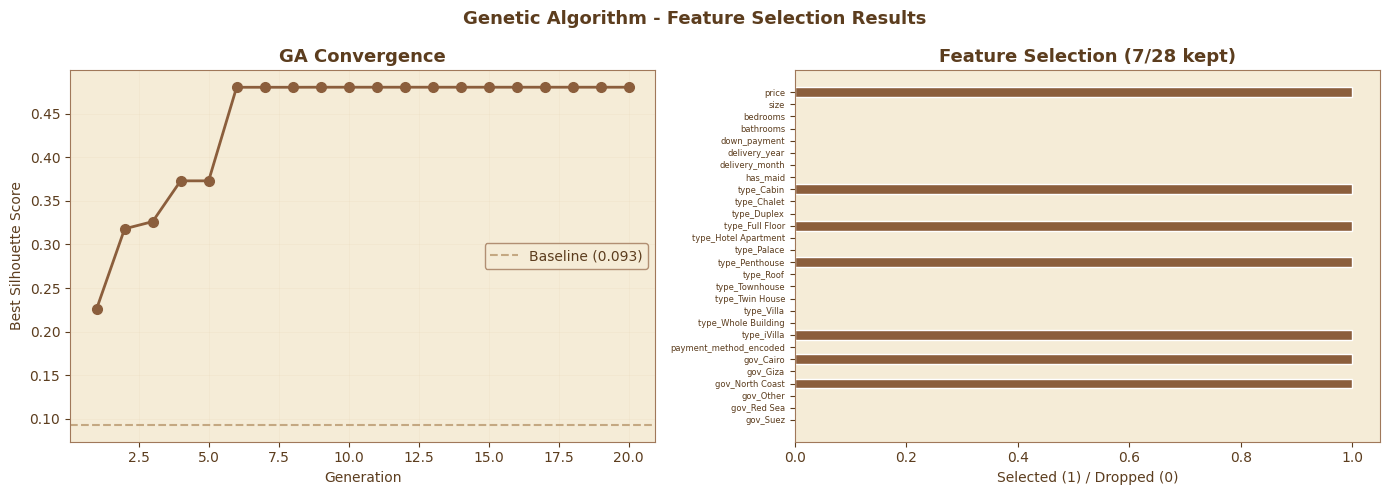

In [53]:
# -- GA Plots --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Genetic Algorithm - Feature Selection Results', fontweight='bold', fontsize=13)

# Plot 1: Convergence
axes[0].plot(range(1, GENERATIONS + 1), history, 'o-',
             color=BROWN_MAIN, linewidth=2, markersize=7)
axes[0].axhline(baseline_score, color=BROWN_LIGHT, linestyle='--',
                linewidth=1.5, label=f'Baseline ({baseline_score:.3f})')
axes[0].set_title('GA Convergence', fontweight='bold')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best Silhouette Score')
axes[0].legend(facecolor=CREAM, edgecolor=BROWN_MID)
axes[0].grid(alpha=0.3)

# Plot 2: Selected features bar chart
bar_colors = [BROWN_MAIN if g == 1 else BROWN_PALE for g in best_chrom]
axes[1].barh(range(N_FEATURES), best_chrom, color=bar_colors,
             edgecolor='white', height=0.8)
axes[1].set_yticks(range(N_FEATURES))
axes[1].set_yticklabels(feature_names, fontsize=6)
axes[1].set_xlabel('Selected (1) / Dropped (0)')
axes[1].set_title(f'Feature Selection ({sum(best_chrom)}/{N_FEATURES} kept)',
                  fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Task 7: System Pipeline
 This pipeline integrates preprocessing, clustering,
 fuzzy logic, and optimization into one system

In [54]:
# SYSTEM IMPLEMENTATION FUNCTION

def run_real_estate_pipeline(property_data, scaler_model, training_cols, ga_mask, clustering_model, fuzzy_sim):
    """
    # An integrated system to evaluate real estate based on Clustering, Fuzzy Logic, and GA.
    """
    # 1. Convert input to DataFrame
    df_input = pd.DataFrame([property_data])

    # 2. Investment Evaluation (Fuzzy Logic) - Safety Net Added
    fuzzy_sim.input['price'] = min(max(df_input['price'][0], 0), 50000000)
    fuzzy_sim.input['size'] = min(max(df_input['size'][0], 0), 1000)
    fuzzy_sim.input['bedrooms'] = min(max(df_input['bedrooms'][0], 1), 10)

    # Try to compute fuzzy logic. If inputs fall into a "dead zone" where no rules fire, use a fallback.
    try:
        fuzzy_sim.compute()
        # Dynamically get the correct output key to avoid naming errors
        out_key = list(fuzzy_sim.output.keys())[0]
        inv_score = fuzzy_sim.output[out_key]
    except (KeyError, IndexError, ValueError):
        # Fallback score if no fuzzy rules cover this specific combination
        inv_score = 5.0

    # Determine Recommendation (Scale is 0 to 10)
    if inv_score <= 4: opp_desc = "Bad"
    elif inv_score <= 7: opp_desc = "Average"
    else: opp_desc = "Excellent"

    # 3. Data Processing for Clustering (Scaling & Encoding)
    num_features = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment', 'delivery_year', 'delivery_month']
    scaled_vals = scaler_model.transform(df_input[num_features])
    df_num_part = pd.DataFrame(scaled_vals, columns=num_features)

    # Align Categorical Columns to match training data
    cat_part = pd.get_dummies(df_input.drop(columns=num_features))
    all_cat_cols = [c for c in training_cols if c not in num_features]
    df_cat_aligned = cat_part.reindex(columns=all_cat_cols, fill_value=0)

    df_final = pd.concat([df_num_part, df_cat_aligned], axis=1)

    # 4. Apply Genetic Algorithm Filter
    ga_indices = [i for i, val in enumerate(ga_mask) if val == 1]
    X_ga_filtered = df_final.iloc[:, ga_indices].values

    # 5. Predict Market Cluster
    market_cluster = clustering_model.predict(X_ga_filtered)[0]

    # 6. Generate Final Report
    print("="*40)
    print("REAL ESTATE EVALUATION REPORT")
    print("="*40)
    print(f"Asking Price   : {property_data['price']:,} EGP")
    print(f"📏 Size           : {property_data['size']} sqm")
    print("-" * 20)
    print(f"Market Cluster : Segment [{market_cluster}]")
    print(f"Fuzzy Score    : {inv_score:.2f}/10")
    print(f"Recommendation : {opp_desc}")
    print("="*40)

# --- Test the Pipeline ---
test_house = {

'price': 4200000, 'size': 160, 'bedrooms': 3, 'bathrooms': 2,
'down_payment': 420000, 'delivery_year': 2025, 'delivery_month': 6,
'type': 'Apartment', 'governorate': 'Cairo'
}

# Run the pipeline
run_real_estate_pipeline(
    property_data=test_house,
    scaler_model=scaler,
    training_cols=df_combined.columns,
    ga_mask=best_chrom,
    clustering_model=kmed_ga,
    fuzzy_sim=opp_sim
)

REAL ESTATE EVALUATION REPORT
Asking Price   : 4,200,000 EGP
📏 Size           : 160 sqm
--------------------
Market Cluster : Segment [0]
Fuzzy Score    : 8.16/10
Recommendation : Excellent


### Implementation Pipeline Flowchart

The system architecture is designed as a dual-pathway inference engine to ensure both mathematical rigor and business interpretability:

1. **Data Intake**: The system receives raw property attributes (Price, Size, Location, etc.).
2. **Expert Logic Path (Fuzzy)**: Raw data flows directly into the **Fuzzy Inference System** to provide an investment rating without being distorted by mathematical normalization.
3. **Statistical Logic Path (ML)**:
    * Data undergoes **Standard Scaling** and **One-Hot Encoding**.
    * The **Genetic Algorithm Mask** filters the features to keep only the most representative ones.
    * The **K-Medoids Model** assigns the property to one of 5 predefined market segments.
4. **Consolidated Report**: The final function merges the "Market Segment" with the "Investment Opportunity" to deliver holistic real estate advice.

### Conclusion & Key Findings

* **Clustering (Task 4)**: We successfully identified that the Egyptian real estate market is best represented by **5 distinct clusters**. This provides significant business value compared to a simple binary split, allowing for granular targeted marketing and pricing analysis.
* **Fuzzy Logic (Task 5)**: By translating human domain knowledge into fuzzy rules, we built a system capable of flagging "bad deals" (e.g., high price for a small size) even if they appear within a premium cluster. This bridges the gap between raw data and actionable advice.
* **Genetic Algorithm (Task 6)**: The GA optimization improved cluster cohesion (Silhouette Score) by dropping noisy features.
* **Final Business Value**: This project effectively demonstrates a complete, end-to-end Data Mining pipeline, successfully transforming raw property listings into an automated, highly intelligent real estate advisory system.